# Transfer Learning

(Date - 15/June/2026)

## 0. Necessary imports

In [54]:
import torch
from torch import nn
import torchvision
from torchvision import transforms
from torchinfo import summary
import matplotlib.pyplot as plt
import os
import zipfile
from pathlib import Path
import requests
import data_setup
from timeit import default_timer as Timer
import engine
import sys
sys.path.append(str(Path("..").resolve())) # This line is important to import helper functions. It's because our helper_functions.py file is outside this directory.
from helper_functions import plot_loss_curves
import random
from typing import List, Tuple
from PIL import Image
from torchmetrics import ConfusionMatrix
from tqdm.auto import tqdm
from mlxtend.plotting import plot_confusion_matrix
from torchvision.models import googlenet, GoogLeNet_Weights

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

## 1. Get data

In [2]:
# Setup path to data folder
data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi"

# If the image folder doesn't exist, download it and prepare it... 
if image_path.is_dir():
    print(f"{image_path} directory exists.")
else:
    print(f"Did not find {image_path} directory, creating one...")
    image_path.mkdir(parents=True, exist_ok=True)

    # Download pizza, steak, sushi data
    with open(data_path / "pizza_steak_sushi.zip", "wb") as f:
        print("Downloading pizza, steak, sushi data...")
        request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
        f.write(request.content)

    # Unzip pizza, steak, sushi data
    with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
        print("Unzipping pizza, steak, sushi data...") 
        zip_ref.extractall(image_path)

    # Remove zip file
    os.remove(data_path / "pizza_steak_sushi.zip")


data\pizza_steak_sushi directory exists.


In [3]:
train_dir = image_path / "train"
test_dir = image_path / "test"

train_dir, test_dir

(WindowsPath('data/pizza_steak_sushi/train'),
 WindowsPath('data/pizza_steak_sushi/test'))

## 2. Create Datasets and Dataloaders

### 2.1 Creating a transform for `torchvision.models` (manual creation)

In [4]:
manual_transform = transforms.Compose([
    transforms.Resize(size=(224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [5]:
train_dataloader, test_dataloader, class_names = data_setup.create_dataloaders(train_dir=str(train_dir),
                                                                               test_dir=str(test_dir),
                                                                               transform=manual_transform,
                                                                               batch_size=32)

train_dataloader, test_dataloader, class_names

(<torch.utils.data.dataloader.DataLoader at 0x21447663490>,
 ['pizza', 'steak', 'sushi'])

### 2.2 Creating transform for `torchvision.models` (auto creation)

In [6]:
weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT
weights

EfficientNet_B0_Weights.IMAGENET1K_V1

In [7]:
auto_transforms = weights.transforms()
auto_transforms

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BICUBIC
)

In [8]:
train_dataloader, test_dataloader, class_names = data_setup.create_dataloaders(train_dir=str(train_dir),
                                                                               test_dir=str(test_dir),
                                                                               transform=auto_transforms, # perform same data transforms on our own data as the pretrained model
                                                                               batch_size=32)
train_dataloader, test_dataloader, class_names

(<torch.utils.data.dataloader.DataLoader at 0x21447400b10>,
 ['pizza', 'steak', 'sushi'])

## 3. Getting a pre-trained model

(Date - 16/June/2026)

In [9]:
weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT # .DEFAULT = best available weights 
model = torchvision.models.efficientnet_b0(weights=weights).to(device)

In [10]:
summary(model=model,
        input_size=[32,3,224,224],
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"])

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [32, 3, 224, 224]    [32, 1000]           --                   True
├─Sequential (features)                                      [32, 3, 224, 224]    [32, 1280, 7, 7]     --                   True
│    └─Conv2dNormActivation (0)                              [32, 3, 224, 224]    [32, 32, 112, 112]   --                   True
│    │    └─Conv2d (0)                                       [32, 3, 224, 224]    [32, 32, 112, 112]   864                  True
│    │    └─BatchNorm2d (1)                                  [32, 32, 112, 112]   [32, 32, 112, 112]   64                   True
│    │    └─SiLU (2)                                         [32, 32, 112, 112]   [32, 32, 112, 112]   --                   --
│    └─Sequential (1)                                        [32, 32, 112, 112]   [32, 16, 112

Woah! It's a fairly big model... Isn't it?

In [11]:
# Freeze all base layers in the "features" section of the model (the feature extractor) by setting requires_grad=False
for param in model.features.parameters():
    param.requires_grad = False

# We want to freeze the layers because we don't want our model to forget what it had learned...that is, we don't want to interfere with the already learned parameters.

In [12]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

output_shape = len(class_names)

model.classifier = nn.Sequential(
    torch.nn.Dropout(p=0.2, inplace=True),
    torch.nn.Linear(in_features=1280,
                    out_features=output_shape,
                    bias=True)).to(device)

In [13]:
summary(model=model,
        input_size=[32,3,224,224],
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"])

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                                      [32, 3, 224, 224]    [32, 1280, 7, 7]     --                   False
│    └─Conv2dNormActivation (0)                              [32, 3, 224, 224]    [32, 32, 112, 112]   --                   False
│    │    └─Conv2d (0)                                       [32, 3, 224, 224]    [32, 32, 112, 112]   (864)                False
│    │    └─BatchNorm2d (1)                                  [32, 32, 112, 112]   [32, 32, 112, 112]   (64)                 False
│    │    └─SiLU (2)                                         [32, 32, 112, 112]   [32, 32, 112, 112]   --                   --
│    └─Sequential (1)                                        [32, 32, 112, 112]   [32, 

See it? Many layers are frozen (untrainable) because we set `requires_grad=False`.

<img src="../images/Transfer_learning_model_summary.png">

## 4. Training the model

### 4.1 Setting up Loss function and an optimizer

In [14]:
loss_fn = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(params=model.parameters(), lr=0.001)

### 4.2 Training our model (using engine.py)

In [34]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

start_time = Timer()
results = engine.train(model=model,
                       train_dataloader=train_dataloader,
                       test_dataloader=test_dataloader,
                       optimizer=optimizer,
                       loss_fn=loss_fn,
                       epochs=5,
                       device=device)

end_time = Timer()
total_time = end_time - start_time
print(f"[INFO] Total train time : {total_time:.3f} seconds")

 20%|██        | 1/5 [00:21<01:26, 21.58s/it]

Epoch: 1 | train_loss: 0.5138 | train_acc: 0.9414 | test_loss: 0.5939 | test_acc: 0.8665


 40%|████      | 2/5 [00:40<01:00, 20.01s/it]

Epoch: 2 | train_loss: 0.5641 | train_acc: 0.7812 | test_loss: 0.5866 | test_acc: 0.8153


 60%|██████    | 3/5 [00:59<00:38, 19.35s/it]

Epoch: 3 | train_loss: 0.5392 | train_acc: 0.8086 | test_loss: 0.5162 | test_acc: 0.8258


 80%|████████  | 4/5 [01:27<00:22, 22.86s/it]

Epoch: 4 | train_loss: 0.4983 | train_acc: 0.7969 | test_loss: 0.5108 | test_acc: 0.8561


100%|██████████| 5/5 [01:49<00:00, 21.82s/it]

Epoch: 5 | train_loss: 0.4181 | train_acc: 0.9531 | test_loss: 0.4959 | test_acc: 0.8456
[INFO] Total train time : 109.126 seconds


## 5. Evaluate model by plotting loss curves

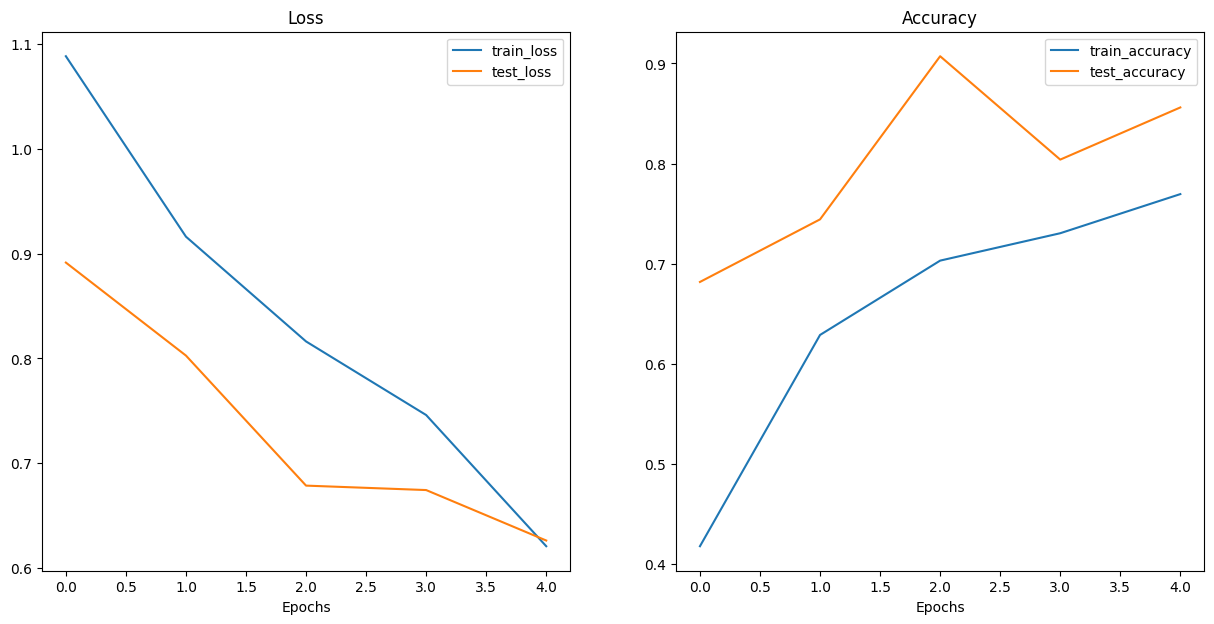

In [16]:
plot_loss_curves(results=results)

## 6. Make predictions on images from the test set

In [17]:
# 1. Take in a trained model, class names, image path, image size, a transform and target device
def pred_and_plot_image(model: torch.nn.Module,
                        image_path: str, 
                        class_names: List[str],
                        image_size: Tuple[int, int] = (224, 224),
                        transform: torchvision.transforms = None,
                        device: torch.device=device):
    
    
    # 2. Open image
    img = Image.open(image_path)

    # 3. Create transformation for image (if one doesn't exist)
    if transform is not None:
        image_transform = transform
    else:
        image_transform = transforms.Compose([
            transforms.Resize(image_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225]),
        ])

    ### Predict on image ### 

    # 4. Make sure the model is on the target device
    model.to(device)

    # 5. Turn on model evaluation mode and inference mode
    model.eval()
    with torch.inference_mode():
      # 6. Transform and add an extra dimension to image (model requires samples in [batch_size, color_channels, height, width])
      transformed_image = image_transform(img).unsqueeze(dim=0)

      # 7. Make a prediction on image with an extra dimension and send it to the target device
      target_image_pred = model(transformed_image.to(device))

    # 8. Convert logits -> prediction probabilities (using torch.softmax() for multi-class classification)
    target_image_pred_probs = torch.softmax(target_image_pred, dim=1)

    # 9. Convert prediction probabilities -> prediction labels
    target_image_pred_label = torch.argmax(target_image_pred_probs, dim=1)

    # 10. Plot image with predicted label and probability 
    plt.figure()
    plt.imshow(img)
    plt.title(f"Pred: {class_names[target_image_pred_label]} | Prob: {target_image_pred_probs.max():.3f}")
    plt.axis(False);

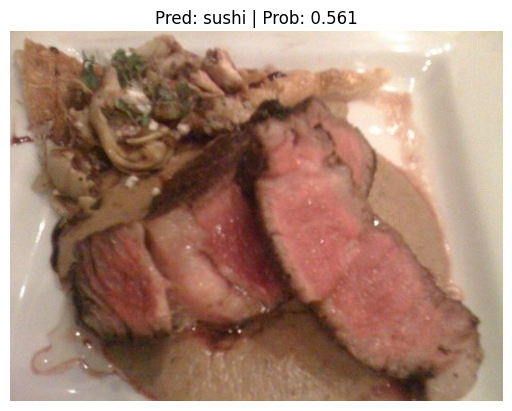

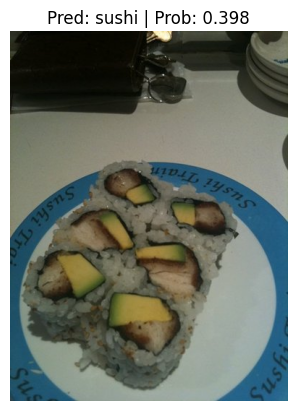

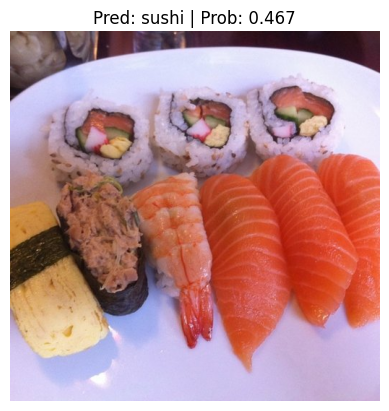

In [18]:
num_images_to_plot = 3
test_image_path_list = list(Path(test_dir).glob("*/*.jpg")) # get list all image paths from test data 
test_image_path_sample = random.sample(population=test_image_path_list, # go through all of the test image paths
                                       k=num_images_to_plot) # randomly select 'k' image paths to pred and plot

# Make predictions on and plot the images
for image_path in test_image_path_sample:
    pred_and_plot_image(model=model, 
                        image_path=str(image_path),
                        class_names=class_names,
                        # transform=weights.transforms(), # optionally pass in a specified transform from our pretrained model weights
                        image_size=(224, 224))

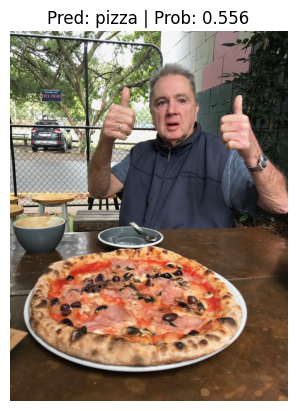

In [19]:
custom_image_path = "custom_image.jpeg"
pred_and_plot_image(model=model,
                    image_path=custom_image_path,
                    class_names=class_names)

# Exercises

(Date - 17/June/2026)

1. Make predictions on the entire test dataset and plot a confusion matrix for the results of our model compared to the truth labels. Check out 03. PyTorch Computer Vision section 10 for ideas.

In [20]:
label_preds = []
label_truth = []
label_pred_probs_list = []
model.eval()
with torch.inference_mode():
    for img, label in tqdm(test_dataloader):
        img, label = img.to(device), label.to(device)
        label_logit = model(img)
        label_pred = torch.softmax(label_logit, dim=1).argmax(dim=1)
        label_pred_probs = torch.softmax(label_logit, dim=1).max(dim=1).values
        label_preds.append(label_pred.cpu())
        label_truth.append(label)
        label_pred_probs_list.append(label_pred_probs)
    
label_pred_probs_list = torch.cat(label_pred_probs_list)
label_pred_tensor = torch.cat(label_preds)
label_truth_tensor = torch.cat(label_truth)
label_pred_tensor[:10], label_pred_probs_list

100%|██████████| 3/3 [00:05<00:00,  1.89s/it]


(tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
 tensor([0.7864, 0.6261, 0.6755, 0.6555, 0.5647, 0.5067, 0.6319, 0.6220, 0.7628,
         0.7643, 0.4897, 0.6466, 0.5554, 0.4298, 0.5678, 0.4822, 0.4268, 0.6027,
         0.7218, 0.7353, 0.5259, 0.4993, 0.5753, 0.6668, 0.4778, 0.8051, 0.8138,
         0.4328, 0.7196, 0.4121, 0.8244, 0.7756, 0.7098, 0.6844, 0.3674, 0.8365,
         0.8401, 0.5753, 0.3774, 0.8268, 0.8132, 0.7426, 0.6772, 0.5462, 0.5311,
         0.4178, 0.4718, 0.4135, 0.6197, 0.8426, 0.6116, 0.4505, 0.5190, 0.5376,
         0.6761, 0.4164, 0.5622, 0.7322, 0.3687, 0.6397, 0.4105, 0.7942, 0.4069,
         0.4758, 0.3953, 0.4520, 0.4762, 0.6005, 0.6895, 0.6315, 0.4743, 0.4570,
         0.3988, 0.4390, 0.5752]))

In [21]:
label_truth_tensor[:10]

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

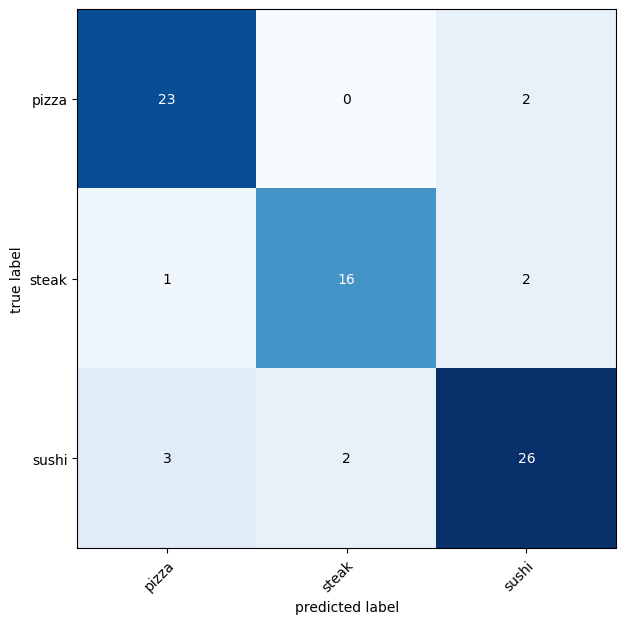

In [22]:
confmat = ConfusionMatrix(num_classes=len(class_names), task='multiclass')
confmat_tensor = confmat(preds=label_pred_tensor, 
                         target=label_truth_tensor)

fig, ax = plot_confusion_matrix(conf_mat=confmat_tensor.numpy(),
                                class_names=class_names,
                                figsize=(16,7))

2. Get the "most wrong" of the predictions on the test dataset and plot the 5 "most wrong" images. You can do this by:
* Predicting across all of the test dataset, storing the labels and predicted probabilities.
* Sort the predictions by wrong prediction and then descending predicted probabilities, this will give you the wrong predictions with the highest prediction probabilities, in other words, the "most wrong".
* Plot the top 5 "most wrong" images, why do you think the model got these wrong?

In [23]:
len(label_truth_tensor), len(label_pred_tensor)

(75, 75)

In [24]:
i = 0
wrong_pred_probs = []
wrong_pred_indices = []
wrong_pred_labels = []
while i<75:
    if label_truth_tensor[i] != label_pred_tensor[i]:
        wrong_pred_indices.append(i)
        wrong_pred_probs.append(label_pred_probs_list[i].item())
        wrong_pred_labels.append(label_pred_tensor[i].item())
    i+=1


pairs = list(zip(wrong_pred_probs, wrong_pred_indices, wrong_pred_labels))
pairs


[(0.5554171204566956, 12, 2),
 (0.42684465646743774, 16, 2),
 (0.4328032433986664, 27, 2),
 (0.41214531660079956, 29, 0),
 (0.3774491548538208, 38, 2),
 (0.47183096408843994, 46, 0),
 (0.41642138361930847, 55, 1),
 (0.368681937456131, 58, 0),
 (0.3953194320201874, 64, 0),
 (0.47428470849990845, 70, 1)]

In [25]:
wrong_pred_probs_descending = sorted(pairs, reverse=True)
wrong_pred_probs_descending

[(0.5554171204566956, 12, 2),
 (0.47428470849990845, 70, 1),
 (0.47183096408843994, 46, 0),
 (0.4328032433986664, 27, 2),
 (0.42684465646743774, 16, 2),
 (0.41642138361930847, 55, 1),
 (0.41214531660079956, 29, 0),
 (0.3953194320201874, 64, 0),
 (0.3774491548538208, 38, 2),
 (0.368681937456131, 58, 0)]

In [26]:
top_5_wrong_pred_probs = wrong_pred_probs_descending[:5]
top_5_wrong_pred_probs

[(0.5554171204566956, 12, 2),
 (0.47428470849990845, 70, 1),
 (0.47183096408843994, 46, 0),
 (0.4328032433986664, 27, 2),
 (0.42684465646743774, 16, 2)]

In [27]:
dataset = test_dataloader.dataset
img, label = dataset[70]

In [28]:
wrong_prob = []
wrong_img_index = []
wrong_labels = []
for prob, index, label in top_5_wrong_pred_probs:
    wrong_prob.append(prob)
    wrong_img_index.append(index)
    wrong_labels.append(label)


In [29]:
wrong_img_index, wrong_labels

([12, 70, 46, 27, 16], [2, 1, 0, 2, 2])

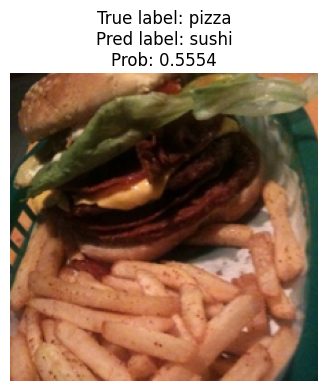

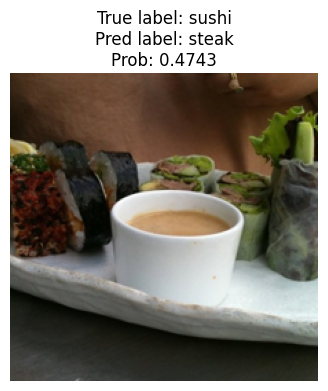

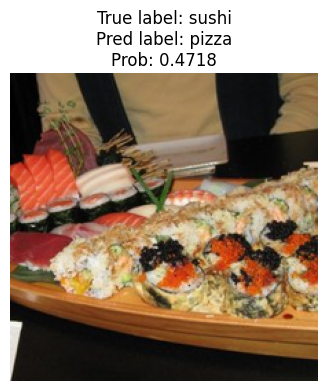

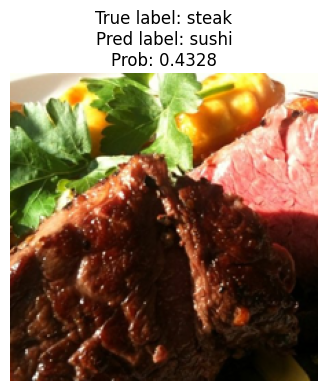

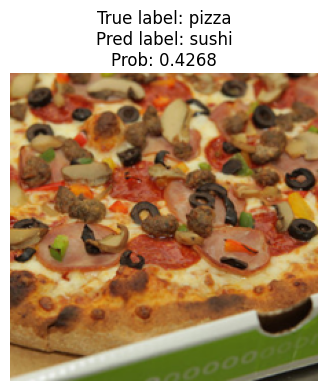

In [30]:
k = 0
for wrong_index in wrong_img_index:
    img, label = dataset[wrong_index]
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

    img = img * std + mean
    img = img.clamp(0,1)

    plt.figure(figsize=(4,4))
    plt.imshow(img.permute(1,2,0))
    plt.title(f"True label: {class_names[label]}\nPred label: {class_names[wrong_labels[k]]}\nProb: {wrong_prob[k]:.4f}")
    plt.axis("off")
    plt.show()
    k+=1

(Date - 18/June/2026)

3. Predict on your own image of pizza/steak/sushi - how does the model go? What happens if you predict on an image that isn't pizza/steak/sushi?

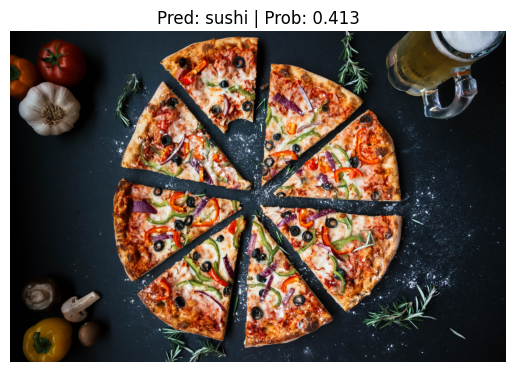

In [37]:
pred_and_plot_image(image_path="custom_pizza_img.jpg",
                    model=model,
                    class_names=class_names)

wrong!

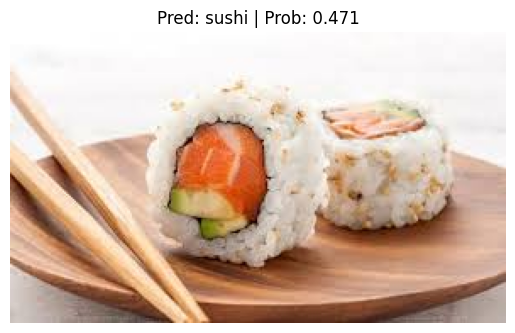

In [35]:
pred_and_plot_image(image_path="custom_sushi_image.jfif",
                    model=model,
                    class_names=class_names)

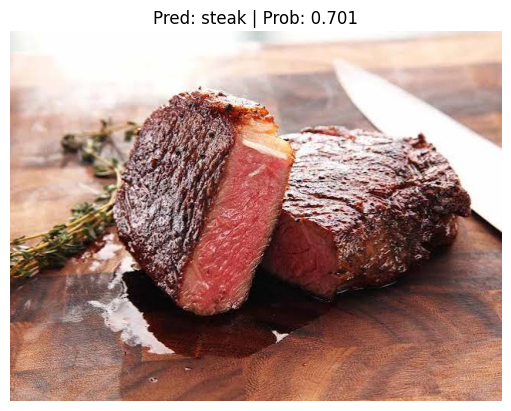

In [36]:
pred_and_plot_image(image_path="custom_steak_img.jfif",
                    model=model,
                    class_names=class_names)

Well! The above two were correct.

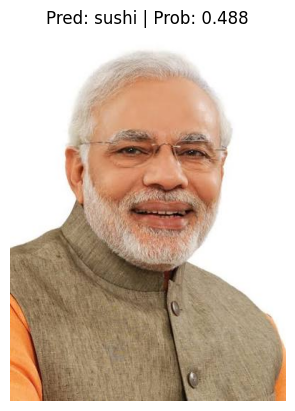

In [38]:
pred_and_plot_image(image_path="modiji_image.jfif",
                    model=model,
                    class_names=class_names)

Modi ji = Sushi?

4. Train the model from section 4 above for longer (10 epochs should do), what happens to the performance?

Done!<br>
Result - The loss goes down, while the accuracy increases... The prediction probability increases but still some predictions are wrong (e.g. the above custom pizza image and modi ji... like 0.488 probability? (Note - labelling him (modi ji) as sushi isn't the problem, but such a high probability is.)) 

5. Train the model from section 4 above with more data, say 20% of the images from Food101 of Pizza, Steak and Sushi images.
* You can find the 20% Pizza, Steak, Sushi dataset on the course GitHub. It was created with the notebook extras/04_custom_data_creation.ipynb.

In [41]:
data_path_20 = Path("20_pizza_steak_sushi/")

train_dir_20 = data_path_20 / "train"
test_dir_20 = data_path_20 / "test"

In [43]:
train_dataloader_20, test_dataloader_20, class_names = data_setup.create_dataloaders(train_dir=str(train_dir_20),
                                                                               test_dir=str(test_dir_20),
                                                                               transform=manual_transform,
                                                                               batch_size=32)

train_dataloader_20, test_dataloader_20, class_names

(<torch.utils.data.dataloader.DataLoader at 0x214d06dc2d0>,
 ['pizza', 'steak', 'sushi'])

In [44]:
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(params=model.parameters(),
                             lr=0.001)

In [45]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

start_time = Timer()
results = engine.train(model=model,
                       train_dataloader=train_dataloader_20,
                       test_dataloader=test_dataloader_20,
                       optimizer=optimizer,
                       loss_fn=loss_fn,
                       epochs=5,
                       device=device)

end_time = Timer()
total_time = end_time - start_time
print(f"[INFO] Total train time : {total_time:.3f} seconds")

 20%|██        | 1/5 [00:39<02:36, 39.01s/it]

Epoch: 1 | train_loss: 0.5137 | train_acc: 0.8271 | test_loss: 0.3528 | test_acc: 0.9256


 40%|████      | 2/5 [01:11<01:45, 35.10s/it]

Epoch: 2 | train_loss: 0.4531 | train_acc: 0.8729 | test_loss: 0.3305 | test_acc: 0.9256


 60%|██████    | 3/5 [01:44<01:08, 34.30s/it]

Epoch: 3 | train_loss: 0.3826 | train_acc: 0.8750 | test_loss: 0.2928 | test_acc: 0.9290


 80%|████████  | 4/5 [02:18<00:34, 34.11s/it]

Epoch: 4 | train_loss: 0.3322 | train_acc: 0.8958 | test_loss: 0.2759 | test_acc: 0.9472


100%|██████████| 5/5 [02:51<00:00, 34.23s/it]

Epoch: 5 | train_loss: 0.3867 | train_acc: 0.8979 | test_loss: 0.2799 | test_acc: 0.9290
[INFO] Total train time : 171.165 seconds


6. Try a different model from torchvision.models on the Pizza, Steak, Sushi data, how does this model perform?
* You'll have to change the size of the classifier layer to suit our problem.
* You may want to try an EfficientNet with a higher number than our B0, perhaps torchvision.models.efficientnet_b2()?

In [55]:
weights = GoogLeNet_Weights.DEFAULT
model = googlenet(weights=weights)

Downloading: "https://download.pytorch.org/models/googlenet-1378be20.pth" to C:\Users\user/.cache\torch\hub\checkpoints\googlenet-1378be20.pth


100%|██████████| 49.7M/49.7M [00:36<00:00, 1.43MB/s]


In [56]:
summary(model=model,
        input_size=[32,3,224,224],
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"])

Layer (type (var_name))                  Input Shape          Output Shape         Param #              Trainable
GoogLeNet (GoogLeNet)                    [32, 3, 224, 224]    [32, 1000]           --                   True
├─BasicConv2d (conv1)                    [32, 3, 224, 224]    [32, 64, 112, 112]   --                   True
│    └─Conv2d (conv)                     [32, 3, 224, 224]    [32, 64, 112, 112]   9,408                True
│    └─BatchNorm2d (bn)                  [32, 64, 112, 112]   [32, 64, 112, 112]   128                  True
├─MaxPool2d (maxpool1)                   [32, 64, 112, 112]   [32, 64, 56, 56]     --                   --
├─BasicConv2d (conv2)                    [32, 64, 56, 56]     [32, 64, 56, 56]     --                   True
│    └─Conv2d (conv)                     [32, 64, 56, 56]     [32, 64, 56, 56]     4,096                True
│    └─BatchNorm2d (bn)                  [32, 64, 56, 56]     [32, 64, 56, 56]     128                  True
├─BasicConv2d (c

In [57]:
for param in model.parameters():
    param.requires_grad = False

In [58]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

output_shape = len(class_names)

model.fc = nn.Linear(model.fc.in_features, output_shape)

In [59]:
summary(model=model,
        input_size=[32,3,224,224],
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"])

Layer (type (var_name))                  Input Shape          Output Shape         Param #              Trainable
GoogLeNet (GoogLeNet)                    [32, 3, 224, 224]    [32, 3]              --                   Partial
├─BasicConv2d (conv1)                    [32, 3, 224, 224]    [32, 64, 112, 112]   --                   False
│    └─Conv2d (conv)                     [32, 3, 224, 224]    [32, 64, 112, 112]   (9,408)              False
│    └─BatchNorm2d (bn)                  [32, 64, 112, 112]   [32, 64, 112, 112]   (128)                False
├─MaxPool2d (maxpool1)                   [32, 64, 112, 112]   [32, 64, 56, 56]     --                   --
├─BasicConv2d (conv2)                    [32, 64, 56, 56]     [32, 64, 56, 56]     --                   False
│    └─Conv2d (conv)                     [32, 64, 56, 56]     [32, 64, 56, 56]     (4,096)              False
│    └─BatchNorm2d (bn)                  [32, 64, 56, 56]     [32, 64, 56, 56]     (128)                False
├─Basic

In [60]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

start_time = Timer()
results = engine.train(model=model,
                       train_dataloader=train_dataloader_20,
                       test_dataloader=test_dataloader_20,
                       optimizer=optimizer,
                       loss_fn=loss_fn,
                       epochs=5,
                       device=device)

end_time = Timer()
total_time = end_time - start_time
print(f"[INFO] Total train time : {total_time:.3f} seconds")

 20%|██        | 1/5 [01:00<04:01, 60.28s/it]

Epoch: 1 | train_loss: 1.1304 | train_acc: 0.3542 | test_loss: 1.1174 | test_acc: 0.2943


 40%|████      | 2/5 [02:03<03:06, 62.02s/it]

Epoch: 2 | train_loss: 1.1261 | train_acc: 0.3521 | test_loss: 1.1163 | test_acc: 0.2915


 60%|██████    | 3/5 [03:02<02:01, 60.72s/it]

Epoch: 3 | train_loss: 1.1108 | train_acc: 0.3646 | test_loss: 1.1154 | test_acc: 0.3131


 80%|████████  | 4/5 [04:03<01:00, 60.78s/it]

Epoch: 4 | train_loss: 1.1148 | train_acc: 0.3854 | test_loss: 1.1139 | test_acc: 0.3097


100%|██████████| 5/5 [05:03<00:00, 60.75s/it]

Epoch: 5 | train_loss: 1.1188 | train_acc: 0.3604 | test_loss: 1.1153 | test_acc: 0.3102
[INFO] Total train time : 303.774 seconds


Trash! (I am not gonnna try `torchvision.models.efficientnet_b2()`)